# Généralités
## Définition et propriétés
### Définition 
Un conteneur (container en anglais) est un nom générique pour définir un objet Python qui contient une collection
d’autres objets.

Les conteneurs que nous connaissons depuis le début de ce cours sont les *listes*, les *chaînes de caractères*, les *dictionnaires* et les *tuples*. Même si on ne l’a pas vu explicitement, les objets de type *range* sont également des conteneurs.
Dans la suite de cette rubrique, nous allons examiner les différentes propriétés des conteneurs. À la fin de ce chapitre,
nous ferons un tableau récapitulatif de ces propriétés.


Examinons d’abord les propriétés qui caractérisent tous les types de conteneur.
- Capacité à supporter le test d’appartenance. Souvenez-vous, il permet de vérifier si un élément était présent dans
une liste. Cela fonctionne donc aussi sur les chaînes de caractères ou tout autre conteneur :

In [1]:
liste1 =[1,2,3]
4 in liste1
"pa" in "papa"

True

- Capacité à supporter la fonction len() renvoyant la longueur du conteneur.  

Voici d’autres propriétés générales que nous avons déjà croisées. Un conteneur peut être :
+ Ordonné (ordered en anglais) : il y a un ordre précis des éléments; cet ordre correspond à celui utilisé lors de la
création ou de la modification du conteneur (si cela est permis) ; ce même ordre est utilisé lorsqu’on itère dessus.
+ Indexable (subscriptable en anglais) : on peut retrouver un élément par son indice (c’est-à-dire sa position dans le
conteneur) ou plusieurs éléments avec une tranche ; en général, tout conteneur indexable est ordonné.
+ Itérable (iterable en anglais) : on peut faire une boucle dessus.

Certains conteneurs sont appelés objets séquentiels ou séquence.

### Définition 
Un objet séquentiel ou séquence est un conteneur itérable, ordonné et indexable. Les objets séquentiels sont les
listes, les chaînes de caractères, les objets de type range, ainsi que les tuples.

Une autre propriété importante que l’on a déjà croisée, et qui nous servira dans ce chapitre, concerne la possibilité
ou non de modifier un objet.
* Un objet est dit non modifiable lorsqu’on ne peut pas le modifier, ou lorsqu’on ne peut pas en modifier un de
ses éléments si c’est un conteneur. On parle aussi d’objet immuable [lien](https://fr.wikipedia.org/wiki/Objet_immuable)
(immutable object en anglais). Cela signifie
qu’une fois créé, Python ne permet plus de le modifier par la suite. 

Qu’en est-il des objets que nous connaissons ? Les listes sont modifiables, on peut modifier un ou plusieurs de ses
éléments et ajouter ou retirer un élément. Les dictionnaires sont modifiables : pour une clé donnée, on peut changer la
valeur correspondante et ajouter ou retirer un couple clé/valeur. Tous les autres types que nous avons vus précédemment
sont quant à eux non modifiables : les chaînes de caractères ou strings, les tuples, les objets de type range, mais également
des objets qui ne sont pas des conteneurs comme les entiers, les floats et les booléens.

On comprend bien l’immutabilité des strings comme vu au chapitre *Plus sur les chaînes de caractères*, mais c’est
moins évident pour les entiers, floats ou booléens. Nous allons démontrer cela, mais avant nous avons besoin de définir
la notion d’identifiant d’un objet.

### Définition 
L’identifiant d’un objet est un nombre entier qui est garanti constant pendant toute la durée de vie de l’objet. Cet
identifiant est en général unique pour chaque objet. Toutefois, pour des raisons d’optimisation, Python crée parfois le
même identifiant pour deux objets non modifiables différents qui ont la même valeur. L’identifiant peut être assimilé
à l’adresse mémoire de l’objet qui, elle aussi, est unique. En Python, on utilise la fonction interne id() qui prend en
argument un objet et renvoie son identifiant.

Maintenant que l’identifiant est défini, regardons l’exemple suivant qui montre l’immutabilité des entiers :

In [4]:
x=4
id(x)

140734765222424

In [5]:
x=5
id(x)

140734765222456

L’affectation x = 5 écrase l’ancienne variable x et en crée une nouvelle, ce n’est pas la valeur de x qui a été changée puisque l’identifiant n’est plus le même. Le même raisonnement peut être tenu pour les autres types numériques comme les floats et booléens. Si
on regarde maintenant ce qu’il se passe pour une liste :

In [10]:
liste1 = [1,2,3]
id(liste1)

1907485995008

In [11]:
liste1[1]=-15
print(liste1, id(liste1))

[1, -15, 3] 1907485995008


In [12]:
liste1.append(4)
print(liste1, id(liste1))

[1, -15, 3, 4] 1907485995008


La liste liste1 a été modifiée (changement de l’élément d’indice 1 et ajout d’un élément). Pour
autant, l’identifiant de cette liste est resté identique tout du long. Ceci démontre la mutabilité des listes : quelle que soit
la manière dont on modifie une liste, celle-ci garde le même identifiant.

* Une dernière propriété importante est la capacité d’un conteneur (ou tout autre objet Python) à être hachable.

### Définition
Un objet Python est dit hachable (hashable en anglais) s’il est possible de calculer une valeur de hachage sur celui-ci
avec la fonction interne hash(). En programmation, la valeur de hachage peut être vue comme une empreinte numérique
de l’objet. Elle est obtenue en passant l’objet dans une fonction de hachage et dépend du contenu de l’objet. En Python,
cette empreinte est, comme dans la plupart des langages de programmation, un entier. Au sein d’une même session
Python, deux objets hachables qui ont un contenu identique auront strictement la même valeur de hachage.

### Attention
La valeur de hachage d’un objet renvoyée par la fonction hash() n’a pas le même sens que son identifiant renvoyé
par la fonction id(). La valeur de hachage est obtenue en « moulinant » le contenu de l’objet dans une fonction de
hachage. L’identifiant est quant à lui attribué par Python à la création de l’objet. Il est constant tout le long de la durée
de vie de l’objet, un peu comme une carte d’identité. Tout objet a un identifiant, mais il doit être hachable pour avoir
une valeur de hachage.


Pourquoi évoquer cette propriété de hachabilité? D’abord, parce qu’elle est étroitement liée à l’immutabilité. En effet,
un objet non modifiable est la plupart du temps hachable. Cela permet de l’identifier en fonction de son contenu. Par
ailleurs, l’hachabilité est une implémentation qui permet un accès rapide aux éléments des conteneurs de type dictionnaire
ou set (cf. rubriques suivantes).

Les objets hachables sont les chaînes de caractères, les entiers, les floats, les booléens, les objets de type range, les
tuples (sous certaines conditions) et les frozensets ; par contre, les listes, les sets et les dictionnaires sont non hachables.
Les sets et frozensets seront vus plus bas dans ce chapitre.
Voici un exemple :

In [14]:
print(hash("Plouf"),
hash(5),
hash(3.14))
hash([1, 2, 3])

-1841448339128306862 5 322818021289917443


TypeError: unhashable type: 'list'

Les valeurs de hachage renvoyées par la fonction hash() de Python sont systématiquement des entiers. Par contre,
Python renvoie une erreur pour une liste, car elle est non hachable.

## Conteneurs de type range
Revenons rapidement sur les objets de type range. Jusqu’à maintenant, on s’en est servi pour faire des boucles ou
générer des listes de nombres. Toutefois, on a vu ci-dessus qu’ils étaient aussi des conteneurs. Ils sont ordonnés, indexables,
itérables, hachables et non modifiables :

In [21]:
range1 = range(3)
print(range1, range1[0], range1[1], range1[2], range1[0:1])

range(0, 3) 0 1 2 range(0, 1)


In [22]:
for element in range1:
    print(element)

0
1
2


In [23]:
range1[2] = 10

TypeError: 'range' object does not support item assignment

In [24]:
hash(range1)

-8338477496398685190

La tentative de modification d’un élément conduit à la même erreur que lorsqu’on essaie de modifier un
caractère d’une chaîne de caractères. Comme pour la plupart des objets Python non modifiables, les objets de type range
sont hachables.

# Plus sur les dictionnaires
Nous revenons sur les dictionnaires qui, on l’a vu, sont des conteneurs de correspondance où chaque valeur est associée
à une clé plutôt qu’un indice. Nous allons voir certaines propriétés avancées des dictionnaires, notamment comment trier
par clé ou par valeur.

### Objets utilisables comme clé
Toutes les clés de dictionnaire vues dans le chapitre *Dictionnaires et tuples* et utilisées jusqu’à présent étaient des
chaînes de caractères. Toutefois, on peut utiliser d’autres types d’objets comme des entiers, des floats, voire des tuples,
cela peut s’avérer parfois très utile. Une règle est toutefois requise : les objets utilisés comme clé doivent être hachables.

Pourquoi les clés doivent être des objets hachables ? C’est la raison d’être des dictionnaires qui d’ailleurs sont aussi
appelés table de hachage dans d’autres langages, comme Perl. Convertir chaque clé en sa valeur de hachage permet
un accès très rapide à chacun des éléments du dictionnaire, ainsi que des comparaisons de clés entre dictionnaires
extrêmement efficaces. Même si on a vu que deux objets pouvaient avoir la même valeur de hachage, par exemple a = 5
et b = 5, on ne peut mettre qu’une seule fois la clé 5. Ceci assure que deux clés d’un même dictionnaire ont forcément
une valeur de hachage différente.

Pouvoir utiliser autre chose qu’une chaîne de caractères comme clé peut se révéler très pratique. Prenons un exemple en mathématiques : on veut représenter un polynôme avec comme clé l’exposant et comme valeur le coefficient.

Exemple avec le polynôme :  

$P(x) = 2x^3 + 5x^2 - 1$

In [25]:
# Polynôme : 2x^3 + 5x^2 - 1
polynome = {3: 2, 2: 5, 0: -1}

# Accès direct au coefficient de x²
print(polynome[2])  # 5

# Parcours du polynôme
for exposant, coefficient in polynome.items():
    print(f"x^{exposant} -> {coefficient}")

5
x^3 -> 2
x^2 -> 5
x^0 -> -1


### Destruction d’une paire clé/valeur
Comme pour tous les objets Python, l’instruction *del* permet de détruire un couple clé/valeur :

In [27]:
dico = {'nom': 'girafe', 'taille': 5.0, 'poids': 1100}
del dico["nom"]
dico
# Pour les listes, on utilise l’indice entre crochet pour détruire l’élément, par exemple del liste[2]. Ici, on utilise la clé.

{'taille': 5.0, 'poids': 1100}

### Tri par clés
On peut utiliser la fonction sorted() vue précédemment avec les listes pour trier un dictionnaire par ses clés :

In [29]:
ani2 = {'nom': 'singe', 'taille': 1.75, 'poids': 70}
sorted(ani2)
# Les clés sont triées ici par ordre alphabétique.

['nom', 'poids', 'taille']

### Tri par valeurs
Pour trier un dictionnaire par ses valeurs, il faut utiliser la fonction sorted() avec l’argument key :

In [34]:
dico = {"a": 15, "b": 5, "c":20}
dico.get("a")
sorted(dico, key=dico.get)

['b', 'a', 'c']

L’argument *key=dico.get* indique explicitement qu’il faut réaliser le tri par les valeurs du dictionnaire. Attention, ce sont les clés du dictionnaire qui sont renvoyées, pas les valeurs. Ces clés sont cependant renvoyées dans
un ordre qui permet d’obtenir les clés triées par ordre croissant :

In [35]:
dico = {"a": 15, "b": 5, "c": 20}

for key in sorted(dico, key=dico.get):
    print(key, dico[key])

b 5
a 15
c 20


In [36]:
# Enfin, l’argument reverse=True fonctionne également :
dico = {"a": 15, "b": 5, "c": 20}
sorted(dico, key=dico.get, reverse=True)

['c', 'a', 'b']

#### Attention : 
le tri par valeurs suppose que les valeurs soient comparables entre elles.
Si le dictionnaire contient à la fois des nombres et des chaînes de caractères, Python ne saura pas effectuer le tri et renverra une erreur.

### Max, Min, Fonction dict()
Les fonctions min() et max(), que vous avez déjà manipulées dans les chapitres précédents, acceptent également
l’argument key=. On peut ainsi obtenir la clé associée au minimum ou au maximum des valeurs d’un dictionnaire.

In [37]:
dico = {"a": 15, "b": 5, "c":20}
max(dico, key=dico.get)

'c'

La fonction dict() va convertir l’argument qui lui est passé en dictionnaire. Il s’agit donc d’une fonction de casting,
comme int(), str(), etc. Toutefois, l’argument qui lui est passé doit avoir une forme particulière : un objet séquentiel
contenant d’autres objets séquentiels de deux éléments.

In [38]:
liste_animaux = [["girafe", 2], ["singe", 3]]
dict(liste_animaux)

{'girafe': 2, 'singe': 3}

Ou un tuple de tuples de deux éléments, ou encore une combinaison liste et tuple. Une manière puissante pour générer des dictionnaires combine les fonctions dict() et zip(). On se souvient que la fonction zip() peut générer une liste de tuples :

In [41]:
animaux = ["poulain", "renard", "python"]
couleurs = ["alezan", "roux", "vert"]
list(zip(animaux, couleurs))
dict(zip(animaux, couleurs))
# Attention à ne passer que deux listes à la fonction zip(), sinon Python renvoie une erreur

{'poulain': 'alezan', 'renard': 'roux', 'python': 'vert'}

## Plus sur les tuples
Nous revenons sur les tuples, que nous avons défini dans le chapitre *Dictionnaires et tuples* et que nous avons
croisé à de nombreuses reprises, notamment avec les fonctions. Les tuples sont des objets séquentiels correspondant aux
listes, donc ils sont itérables, ordonnés et indexables, mais ils sont toutefois non modifiables. On verra plus bas qu’ils
sont hachables sous certaines conditions. L’intérêt des tuples par rapport aux listes réside dans leur immutabilité. Cela
accélère considérablement la manière dont Python accède à chaque élément et ils prennent moins de place en mémoire.
Par ailleurs, on ne risque pas de modifier un de ses éléments par mégarde.
### Immutabilité
Nous avions vu que les tuples étaient immuables :

In [43]:
tuple1 = (1, 2, 3)
tuple1[2] = 15
# Ce message est similaire à celui que nous avions rencontré quand on essayait de modifier une chaîne de caractères

TypeError: 'tuple' object does not support item assignment

Si vous voulez ajouter un élément (ou le modifier), vous devez créer un nouveau tuple :

In [45]:
tuple1 = (1, 2, 3)
tuple1
id(tuple1)

1907492773184

In [46]:
tuple1 = tuple1 + (15,)
tuple1

(1, 2, 3, 15)

In [47]:
id(tuple1)

1907492752656

La fonction *id()* montre que le tuple créé dernièrement est bien différent de celui créé avant, bien qu’ils aient le même
nom. Comme on a vu plus haut, ceci est dû à l’opérateur d’affectation utilisé (tuple1 = tuple1 + (2,)) qui
crée un nouvel objet distinct de celui d'avant. Cet exemple montre que les tuples sont peu adaptés lorsqu’on a besoin
d’ajouter, retirer, modifier des éléments. La création d’un nouveau tuple à chaque étape s’avère lourde et il n’y a aucune
méthode pour faire cela, puisque les tuples sont non modifiables.

### Affectation multiple et fonctions
Dans le chapitre* Dictionnaires et tuples*, nous avons abordé l’affectation multiple. Pour rappel, elle permet d’effectuer
sur une même ligne plusieurs affectations en même temps, par exemple : $x, y, z = 1, 2, 3$. On a vu qu’il était possible
de le faire également avec les listes : $[x, y, z] = [1, 2, 3]$. Toutefois, cette syntaxe étant alourdie par la présence
des crochets, on préfèrera toujours la première syntaxe avec les tuples sans parenthèses.
Concernant les fonctions, nous avions croisé l’importance de l’affectation multiple dans le chapitre 10 lorsqu’une
fonction renvoyait plusieurs valeurs :


In [48]:
def ma_fonction():
    return 3, 14
x, y = ma_fonction()
print(x, y)

3 14


La syntaxe *x, y = ma_fonction()* permet de récupérer les deux valeurs renvoyées par la fonction et de les affecter
à la volée dans deux variables différentes. Cela évite l’opération laborieuse de récupérer d’abord le tuple, puis de créer les
variables en utilisant l’indiçage :

In [50]:
resultat = ma_fonction()
resultat
x = resultat[0]
y = resultat[1]
print(x, y)

# Lorsqu’une fonction renvoie plusieurs valeurs sous forme de tuple, privilégiez toujours la forme x, y = ma_fonction().

3 14


Quand une fonction renvoie plusieurs valeurs, mais que l’on ne souhaite pas les utiliser toutes dans la suite du code,
on peut utiliser le nom de variable _ (caractère underscore) pour indiquer que certaines valeurs ne nous intéressent pas :

In [53]:
def ma_fonction():
    return 1, 2, 3, 4

x, _, y, _ = ma_fonction()
x
y

3

Cela envoie le message à la personne qui lit le code « je ne m’intéresse pas aux valeurs récupérées dans les variables
_ ». Notez que l’on peut utiliser une ou plusieurs variables underscore(s). Dans l’exemple ci-dessus, la 2e et la 4e variable
renvoyées par la fonction seront ignorées dans la suite du code. Cela présente le mérite d’éviter de polluer l’attention de
la personne qui lit le code.

#### Remarque
Le caractère underscore (_) est couramment utilisé dans les noms de variable pour séparer les mots et être explicite,
par exemple nb_entiers ou liste_noms. On verra dans le chapitre *Bonnes pratiques en programmation*
Python que ce style de nommage est appelé snake_case. Toutefois, il faut éviter d’utiliser les underscores en début et/ou
en fin de nom de variable (leading et trailing underscores en anglais), par exemple : `_var`, `var_`, `__var`, `__var__`. On
verra au chapitre *Avoir la classe avec les objets* que ces underscores ont aussi une signification particulière.


### Tuples contenant des listes
On a vu que les tuples étaient non modifiables. Que se passe-t-il alors si on crée un tuple contenant des objets
modifiables comme des listes? Examinons le code suivant :

In [59]:
liste1 = [1, 2, 3]
tuple1 = (liste1, "Plouf")
print(tuple1)
liste1[1] = -15
print(liste1, tuple1)



([1, 2, 3], 'Plouf')
[1, -15, 3] ([1, -15, 3], 'Plouf')


La liste ``liste1`` pointe vers le même objet que l’élément du tuple d’indice 0. Comme pour la copie de liste (par exemple liste_b = liste_a), ceci est attendu car, par défaut, Python crée une copie par référence (voir le chapitre *Plus sur les listes*).

Ainsi, qu’on raisonne en tant que premier élément du tuple ou bien en tant que liste ``liste1``, on pointe vers la même liste.

Rappelez-vous que lorsqu’on modifiait un élément d’une liste, celle-ci gardait le même identifiant. C’est toujours le cas ici, même si la liste se trouve dans un tuple.

Regardons cela :

In [60]:
liste1 = [1, 2, 3]
tuple1 = (liste1, "Plouf")
tuple1
print(
id(liste1),
id(tuple1[0]))

1907492608128 1907492608128


Nous confirmons ici le schéma de *Python Tutor*, c’est bien la même liste que l’on considère ``liste1`` ou ``tuple1[0]``
puisqu’on a le même identifiant. Maintenant, on modifie cette liste via la variable ``liste1`` ou ``tuple1[0]`` :

In [62]:
liste1[2] = -15
tuple1[0].append(-632)
print(
tuple1,
id(liste1),
id(tuple1[0])
)

([1, 2, -15, -632, -632], 'Plouf') 1907492608128 1907492608128


Malgré la modification de cette liste, l’identifiant n’a toujours pas changé puisque la fonction id() nous renvoie la
même valeur depuis le début. Même si la liste a été modifiée « de l’intérieur », Python considère que c’est toujours la
même liste, puisqu’elle n’a pas changé d’identifiant. Si au contraire on essaie de remplacer cette sous-liste par autre
chose, Python renvoie une erreur.

#### Conseil
Dans la mesure du possible, nous vous déconseillons de créer des listes dans des tuples afin d’éviter les déconvenues.

## Fonction tuple()
Nous avions vu également la fonction ``tuple()``, qui permet de convertir un objet séquentiel en tuple (opération de
casting). Cela est possible seulement si l’objet passé en argument est itérable :


In [71]:
print(tuple([1, 3]),
tuple("a"))
print(tuple(2))
print(tuple(True))
# Bien sûr, un entier ou un booléen ne sont pas itérables.

(1, 3) ('a',)


TypeError: 'int' object is not iterable

### Hachabilité des tuples
Les tuples sont hachables s’ils ne contiennent que des éléments hachables. Si un tuple contient un ou plusieurs objet(s)
non hachable(s), comme une liste, il devient non hachable :

In [73]:
tuple1 = tuple(range(10))
tuple1
print(hash(tuple1))

tuple2 = ("Plouf", 2, (1, 3))
tuple2
print(hash(tuple2))

tuple3 = (1, (3, 4), "Plaf", [3, 4, 5])
tuple3
print(hash(tuple3))


-2040549277248155741
-4052043136191137033


TypeError: unhashable type: 'list'

Les tuples ``tuple1`` et ``tuple2`` sont hachables car ils ne contiennent que des éléments hachables. Par contre, ``tuple3``
ne l’est pas, car un de ses éléments est une liste.

#### Conseil
Mettre une ou plusieurs liste(s) dans un tuple le rend non hachable. Ceci le rend inutilisable comme clé de dictionnaire
ou, on le verra ci-après, comme élément d’un ``set`` ou d’un ``frozenset``. Donc, à nouveau, ne mettez pas de listes dans vos
tuples!

## Sets et frozensets
### Définition et propriétés
Les objets de type ``set`` représentent un autre type de conteneur qui peut se révéler très pratique. Ils ont la particularité
d’être modifiables, non hachables, non ordonnés, non indexables et de ne contenir qu’une seule copie maximum de chaque
élément. Pour créer un nouveau ``set`` on peut utiliser les accolades :

In [75]:
set1 = {4, 5, 5, 12}
print(set1,
type(set1))

{5, 12, 4} <class 'set'>


Remarquez que la répétition du chiffre $5$ dans la définition du set produit finalement un seul chiffre $5$, car
chaque élément ne peut être présent qu’une seule fois. Comme pour les dictionnaires (jusqu’à la version 3.6), les sets
sont non ordonnés. La manière dont Python les affiche n’a pas de sens en tant que tel et peut être différente de celle
utilisée lors de leur création.

Les sets ne peuvent contenir que des objets hachables. On a déjà eu le cas avec les clés de dictionnaire. Ceci optimise
l’accès à chaque élément du set. Pour rappel, les objets hachables que nous connaissons sont ``les chaînes de caractères,
les tuples, les entiers, les floats, les booléens et les frozensets`` (voir plus bas). Les objets non hachables que l’on connait
sont ``les listes, les sets et les dictionnaires``. Si on essaie tout de même de mettre une liste dans un set, Python renvoie
une erreur :

In [76]:
set1 = {3, 4, "Plouf", (1, 3)}
print(set1)

set2 = {3.14, [1, 2]}  # provoque une erreur car la liste n'est pas hachable


{'Plouf', 3, (1, 3), 4}


TypeError: unhashable type: 'list'

À quoi différencie-t-on un set d’un dictionnaire alors que les deux utilisent des accolades? Le set sera défini seulement
par des valeurs ``{valeur_1, valeur_2, ...}`` alors que le dictionnaire aura toujours des couples clé/valeur ``{clé_1:
valeur_1, clé_2: valeur_2, ...}``.


La fonction interne à Python set() convertit un objet itérable passé en argument en un nouveau set (opération de
casting) :

In [84]:
print(set([1, 2, 4, 1]))
print(set((2, 2, 2, 1)))
print(set(range(5)))
print(set({"clé_1": 1, "clé_2": 2}))
print(set(["ti", "to", "to"]))
print(set("Maître Corbeau et Maître Renard"))

{1, 2, 4}
{1, 2}
{0, 1, 2, 3, 4}
{'clé_2', 'clé_1'}
{'to', 'ti'}
{'t', ' ', 'b', 'r', 'R', 'î', 'o', 'n', 'd', 'e', 'a', 'u', 'M', 'C'}


Nous avons dit plus haut que les sets ne sont ni ordonnés ni indexables, il est donc impossible de récupérer un élément
par sa position. Il est également impossible de modifier un de ses éléments par l’indexation. Par contre, les sets sont itérables :

In [85]:
for element in set1:
    print(element)


Plouf
3
(1, 3)
4


Les sets ne peuvent être modifiés que par des méthodes spécifiques :

In [86]:
set1 = set(range(5))  # {0, 1, 2, 3, 4}
set1.add(4)           # {0, 1, 2, 3, 4} (4 déjà présent, rien n'est ajouté)
set1.add(472)         # {0, 1, 2, 3, 4, 472}
set1.discard(0)       # {1, 2, 3, 4, 472} (supprime l'élément 0)

- ``.add(elem)`` ajoute l’élément elem au set. Si l’élément est déjà présent, il n’est pas ajouté.

- ``.discard(elem)`` supprime l’élément elem du set. Si l’élément n’existe pas, le set reste inchangé.

- Les sets ne sont pas ordonnés et non indexables, donc il n’existe pas de méthode pour insérer un élément à une position précise.

- Les méthodes modifient le set en place et ne renvoient rien, comme ``.append()`` ou ``.remove()`` pour les listes.

- Les opérateurs ``+ et * `` ne sont pas supportés pour les sets.

### Utilité
Les conteneurs de type ``set`` sont très utiles pour rechercher les éléments uniques d’une suite d’éléments. Cela revient
à éliminer tous les doublons. Par exemple :

In [88]:
import random

liste1 = [random.randint(0, 9) for i in range(10)]
print(liste1, set(liste1))

[5, 0, 4, 9, 7, 1, 6, 5, 4, 5] {0, 1, 4, 5, 6, 7, 9}


On peut bien sûr transformer dans l’autre sens un set en liste. Cela permet par exemple d’éliminer les doublons de la
liste initiale, tout en récupérant une liste à la fin :

In [89]:
list(set([7, 9, 6, 6, 7, 3, 8, 5, 6, 7]))

[3, 5, 6, 7, 8, 9]

On peut faire des choses très puissantes. Par exemple, un compteur de lettres en combinaison avec une liste de
compréhension, le tout en une ligne!

In [92]:
seq = "abbcccdddd"
print(seq.count("d"))
print(set(seq))
[(base, seq.count(base)) for base in set(seq)]


4
{'b', 'a', 'd', 'c'}


[('b', 2), ('a', 1), ('d', 4), ('c', 3)]

Les sets permettent aussi l’évaluation d’union ou d’intersection mathématiques en conjonction avec les opérateurs,
respectivement | et & :

In [97]:
liste1 = [3, 3, 5, 1, 3, 4, 1, 1, 4, 4]
liste2 = [3, 0, 3, 3, 1, 1, 1, 2, 2]
print(
set(liste1) | set(liste2),
set(liste1) & set(liste2)
)

{0, 1, 2, 3, 4, 5} {1, 3}


Notez qu’il existe les méthodes ``.union()`` et ``.intersection`` permettant de réaliser ces opérations d’union et
d’intersection :

In [98]:
set(liste1).union(set(liste2))

{0, 1, 2, 3, 4, 5}

L’instruction ``set1.difference(set2)`` renvoie sous la forme d’un nouveau set les éléments de ``set1`` qui ne sont
pas dans ``set2``. Et inversement pour ``set2.difference(set1)`` :

In [99]:
set(liste1).difference(set(liste2))

{4, 5}

Enfin, deux autres méthodes sont très utiles :

In [102]:
liste1 = [0,2,3, 3, 5, 1, 3, 4, 1, 1, 4, 4]
liste2 = [3, 0, 3, 3, 1, 1, 1, 2, 2]
set(liste2).issubset(set(liste1))

True

La méthode ``.issubset()`` indique si un set est inclus dans un autre set. La méthode ``isdisjoint()`` indique si un
set est disjoint d’un autre set, c’est-à-dire, s’ils n’ont aucun élément en commun indiquant que leur intersection est nulle.
Il existe de nombreuses autres méthodes que nous n’abordons pas ici, mais qui peuvent être consultées sur la documentation officielle de Python [lien](https://docs.python.org/3/library/stdtypes.html#set-types-set-frozenset).

### Frozensets
Les ``frozensets`` sont des sets non modifiables et hachables. Ainsi, un set peut contenir des frozensets mais pas l’inverse.
À quoi servent-ils ? Comme la différence entre ``tuple`` et ``liste``, l’immutabilité des frozensets donne l’assurance de ne pas
pouvoir les modifier par erreur. Pour créer un frozenset on utilise la fonction interne ``frozenset()``, qui prend en argument
un objet itérable et le convertit (opération de casting) :

In [105]:
frozen1 = frozenset([3, 3, 5, 1, 3, 4, 1, 1, 4, 4])
frozen2 = frozenset([3, 0, 5, 3, 3, 1, 1, 1, 2, 2])
print(
frozen1,
frozen2
)
# frozen1.add(5)  # Erreur : frozenset est immuable
print(frozen1.union(frozen2))
print(frozen1.intersection(frozen2))



frozenset({1, 3, 4, 5}) frozenset({0, 1, 2, 3, 5})
frozenset({0, 1, 2, 3, 4, 5})
frozenset({1, 3, 5})


Les frozensets ne possèdent bien sûr pas les méthodes de modification des sets (``.add(), .discard(), etc``.) puisqu’ils
sont non modifiables. Par contre, ils possèdent toutes les méthodes de comparaisons de sets (``.union(), .intersection
()``, etc.). Pour aller plus loin sur les sets et les frozensets, voici deux articles sur le site [programiz](https://www.programiz.com/python-programming/set).

## Récapitulation des propriétés des conteneurs
Après ce tour d’horizon des différents conteneurs, voici des tableaux qui résument leurs propriétés. La mention « ``in``
et ``len()`` » indique que l’on peut tester l’appartenance d’un élément à un conteneur avec l’opérateur ``in``, et que l’on peut
connaître le nombre d’éléments du conteneur avec la fonction ``len()``. Les mentions « ``index.`` » et « ``modif.`` » indiquent
respectivement « indexable » et « modifiable ».

### Objets séquentiels
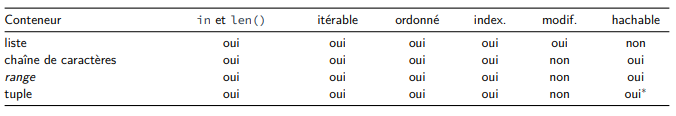  
*s’il ne contient que des objets hachables

### Objet de mapping
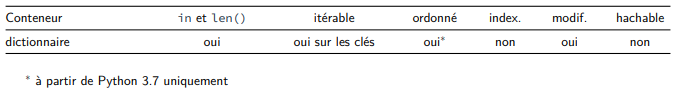

### Objets sets
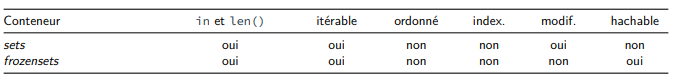

### Types de base
Il est aussi intéressant de comparer ces propriétés avec celles des types numériques de base qui ne sont pas des
conteneurs.
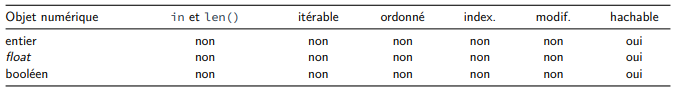

### Copie de conteneurs
Un dernier point qu’il peut être utile de mentionner concerne la copie de conteneurs. On avait vu dans le chapitre
12 Plus sur les listes que la copie de listes se fait par référence. Cela est un mécanisme général pour tous les types de
conteneurs, sauf pour les chaînes de caractères. Python Tutor nous permet de visualiser cela.
Ainsi, il faut toujours faire attention quand on fait une copie d’un conteneur modfiable (liste, dictionnaire, set, etc.).
On verra que Python se comporte de la même manière avec les objets arrays (chapitre *module Numpy*) ou Dataframes
(chapitre *Module pandas*), car on peut les considérer également comme des conteneurs.

## Dictionnaires et sets de compréhension
Nous avons abordé les listes de compréhension dans le chapitre *Plus sur les listes*. Il est également possible de
générer des dictionnaires de compréhension :

In [106]:
# Exemple avec un dictionnaire
dico = {"a": 10, "g": 10, "t": 11, "c": 15}

# Parcourir les items
print(dico.items())
# dict_items([('a', 10), ('g', 10), ('t', 11), ('c', 15)])

# Doubler les valeurs avec une compréhension de dictionnaire
dico_double = {key: val * 2 for key, val in dico.items()}
print(dico_double)
# {'a': 20, 'g': 20, 't': 22, 'c': 30}

# Exemple avec un tuple de paires (animal, nombre)
animaux = (("singe", 3), ("girafe", 4), ("rhinocéros", 2))

# Transformer en dictionnaire
animaux_dict = {animal: nombre for animal, nombre in animaux}
print(animaux_dict)
# {'singe': 3, 'girafe': 4, 'rhinocéros': 2}

dict_items([('a', 10), ('g', 10), ('t', 11), ('c', 15)])
{'a': 20, 'g': 20, 't': 22, 'c': 30}
{'singe': 3, 'girafe': 4, 'rhinocéros': 2}


La méthode ``.items()`` est particulièrement bien adaptée pour créer un
dictionnaire de compréhension, car elle permet d’itérer en même temps sur les clés et valeurs d’un dictionnaire.

Avec un dictionnaire de compréhension, on peut rapidement compter le nombre de chaque base dans une séquence
d’ADN :

In [107]:
seq = "atctcgatcgatcgcgctagctagctcgccatacgtacgactacgt"
{base:seq.count(base) for base in set(seq)}

{'t': 11, 'g': 10, 'a': 10, 'c': 15}

De manière générale, tout objet sur lequel on peut faire une double itération du type for var1, var2 in obj est
utilisable pour créer un dictionnaire de compréhension. Si vous souhaitez aller plus loin, vous pouvez consulter cet article
sur le site [Datacamp](https://www.datacamp.com/tutorial/python-dictionary-comprehension).

Il est également possible de générer des sets de compréhension sur le même modèle que les listes de compréhension :

In [110]:
# Créer un ensemble avec les nombres de 0 à 9
print({i for i in range(10)})

# Créer un ensemble avec les carrés des nombres de 0 à 9
print({i**2 for i in range(10)})

# Créer un ensemble avec les noms d'animaux à partir d'un tuple de paires (nom, nombre)
animaux = (("singe", 3), ("girafe", 4), ("rhinocéros", 2))
{ani for ani, _ in animaux}

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
{0, 1, 64, 4, 36, 9, 16, 49, 81, 25}


{'girafe', 'rhinocéros', 'singe'}

## Module collections

Le module collections contient plusieurs types de conteneurs utiles en Python. Voici quelques exemples :

- Dictionnaires ordonnés (OrderedDict) :
Ils se comportent comme les dictionnaires classiques, mais conservent l’ordre d’insertion des clés lors de l’affichage ou de l’itération. Avant Python 3.6, l’ordre des dictionnaires normaux était arbitraire. Depuis, les dictionnaires classiques se comportent presque comme des dictionnaires ordonnés.


- defaultdict :
Génère automatiquement une valeur par défaut lorsqu’on accède à une clé inexistante, ce qui évite d’obtenir une erreur.

- Compteurs (Counter) :
Permet de compter facilement les éléments d’un objet itérable.

- namedtuple :
Crée des tuples nommés, qui seront abordés plus en détail dans le chapitre sur les objets.

In [ ]:
import collections

# Création d'un compteur à partir d'une chaîne de caractères
compo_seq = collections.Counter("aatctccgatcgatcgatcgatgatc")

print(compo_seq)

print(type(compo_seq))

print(compo_seq["a"])  # 7
print(compo_seq["n"])  # 0

Counter({'a': 7, 't': 7, 'c': 7, 'g': 5})
<class 'collections.Counter'>
7
0
